Imports

In [1]:
%pip install xgboost
%pip install matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import joblib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.7 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 18.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 23.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 30.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]esources]
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Loading Data

In [2]:
# Load + shuffle dataset
df = pd.read_csv("realistic_migraine_data_v2.csv").sample(frac=1, random_state=42)

X = df.drop("Migraine_Score", axis=1)
y = df["Migraine_Score"]

# train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

Training the XGBoost model:

In [3]:
# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predictions
pred = xgb_model.predict(X_test)

Evaluation

In [4]:
# Evaluation
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))
# Save model
joblib.dump(xgb_model, "xgb_migraine_model.pkl")

MAE : 9.046543909047443
RMSE: 11.447646488298084
R²  : 0.6890048954927452


['xgb_migraine_model.pkl']

Visualization

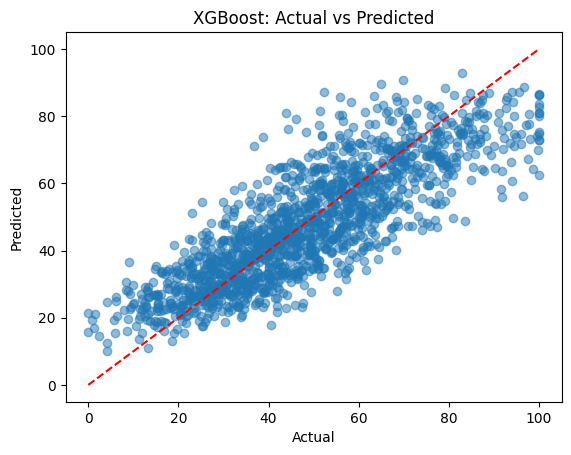

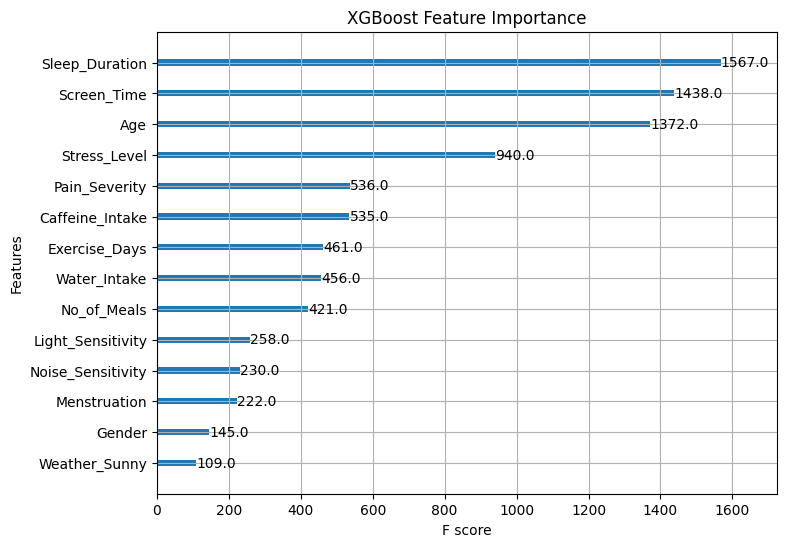

In [5]:
# Visualization: Actual vs Predicted
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

# Feature importance
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(xgb_model, max_num_features=14, ax=ax)
ax.set_title("XGBoost Feature Importance")
plt.show()